# Exploring Chemical Space
Explore some clustering and visualisation models and compare them for two different datasets:
- A subset of ChEMBL small molecule entries with a molecular weight between 200 and 500. Since the entire set of ChEMBL entries is quite substantial, 10k entries were selected by random sampling (`chembl_200-500_10k`)
- The result of the PubChem search for "antibiotics" (`pubchem_antibiotics`).

Note: The ChEMBL dataset may still take quite some processing time - depending on your PC. You can do a random sampling of e.g. 3k entries in order to reduce the computational effort.

Tasks:
1) Load and inspect the two datasets `ChEMBL_200-500_10k.csv`. Note that they are fundamentally different.
2) Perform basic data cleaning and be mindful of which data to dismiss (if any). Hint: Think about standardising column names (at least for the relevant ones)
3) Make sure that the SMILES strings are valid - implement a function to clean up the SMILES returning (in a new column or Series) the canonical SMILES if the input is valid, and return `None` if the SMILES in the original data is not valid (). Hint: The `Normalizer` in  rdkit might be quite useful (https://www.rdkit.org/docs/cppapi/classRDKit_1_1MolStandardize_1_1Normalizer.html)
4) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.
5) Run different clustering techniques, e.g. snippets provided for Butina and HDBSCAN. You can also try the scikit-learn models kmeans or dbscan.
6) Use the fingerprints to run UMAP and TSNE dimensionality reductions (snippets provided).
7) Plot the data in scatterplots, using the cluster labels as colour map.
8) Adjust some parameters of the clustering models and apply filters if needed (e.g. only visualise clusters of a size larger than 10) to reach some satisfactory result
9) Visualise a representative molecule (e.g. centroids or centers of clusters, or random :) ) of the three largest clusters for both methods using rdkit
10) Respond to the discussion points


Import dependencies and datasets

In [1]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem.MolStandardize.rdMolStandardize import Normalizer
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import hdbscan
import umap
from sklearn.manifold import TSNE

###m load data

In [2]:
df_chmbl=pd.read_csv("ChEMBL_200-500_10k.csv")
df_pubchem=pd.read_csv("pubchem_antibiotics.csv")



### look at data

In [3]:

df_list=[df_chmbl, df_pubchem]
for df in df_list:
    print("NaN: ",df.isna().sum().sum())
    print("Duplicated: ",df.duplicated().sum().sum())
    print(df.info())
    print(df.describe())
    print("-"*40)


NaN:  31842
Duplicated:  0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ChEMBL ID           10000 non-null  object 
 1   Name                182 non-null    object 
 2   Synonyms            82 non-null     object 
 3   Type                10000 non-null  object 
 4   Max Phase           75 non-null     float64
 5   Molecular Weight    10000 non-null  float64
 6   Targets             9593 non-null   float64
 7   Bioactivities       9593 non-null   float64
 8   AlogP               9946 non-null   float64
 9   Polar Surface Area  9946 non-null   float64
 10  HBA                 9946 non-null   float64
 11  HBD                 9946 non-null   float64
 12  #RO5 Violations     9946 non-null   float64
 13  #Rotatable Bonds    9946 non-null   float64
 14  Passes Ro3          9946 non-null   object 
 15  QED Weighted        9946 no

Data cleaning

In [4]:
for df in df_list:
    #display(df.head())
    #print("-"*40)
    print(df.columns)

Index(['ChEMBL ID', 'Name', 'Synonyms', 'Type', 'Max Phase',
       'Molecular Weight', 'Targets', 'Bioactivities', 'AlogP',
       'Polar Surface Area', 'HBA', 'HBD', '#RO5 Violations',
       '#Rotatable Bonds', 'Passes Ro3', 'QED Weighted', 'Aromatic Rings',
       'Structure Type', 'Inorganic Flag', 'Heavy Atoms', 'Np Likeness Score',
       'Molecular Formula', 'SMILES', 'Inchi Key', 'Inchi', 'Withdrawn Flag',
       'Orphan', 'Records Key', 'Records Name'],
      dtype='object')
Index(['Compound_CID', 'Name', 'Synonyms', 'Molecular_Formula', 'InChI',
       'Smiles', 'InChIKey', 'IUPAC_Name', 'MeSH_Headings',
       'Annotation_Content', 'Linked_BioAssays', 'Data_Source',
       'Data_Source_Category', 'Tagged_by_PubChem', 'Molecular_Weight',
       'Polar_Area', 'Complexity', 'XLogP', 'Heavy_Atom_Count',
       'H-Bond_Donor_Count', 'H-Bond_Acceptor_Count', 'Rotatable_Bond_Count',
       'Exact_Mass', 'Monoisotopic_Mass', 'Charge', 'Covalent_Unit_Count',
       'Isotopic_Atom_Co

### rename cols

In [5]:
def clean_column_names(df):
    df.columns = (df.columns
               .str.strip()
               .str.lower()
               .str.replace(" ", "_")
               .str.replace("[()€$]", "",regex=True))
    return df

# Clean the column names
for df in df_list:
    clean_column_names(df)
    print(df.columns)

Index(['chembl_id', 'name', 'synonyms', 'type', 'max_phase',
       'molecular_weight', 'targets', 'bioactivities', 'alogp',
       'polar_surface_area', 'hba', 'hbd', '#ro5_violations',
       '#rotatable_bonds', 'passes_ro3', 'qed_weighted', 'aromatic_rings',
       'structure_type', 'inorganic_flag', 'heavy_atoms', 'np_likeness_score',
       'molecular_formula', 'smiles', 'inchi_key', 'inchi', 'withdrawn_flag',
       'orphan', 'records_key', 'records_name'],
      dtype='object')
Index(['compound_cid', 'name', 'synonyms', 'molecular_formula', 'inchi',
       'smiles', 'inchikey', 'iupac_name', 'mesh_headings',
       'annotation_content', 'linked_bioassays', 'data_source',
       'data_source_category', 'tagged_by_pubchem', 'molecular_weight',
       'polar_area', 'complexity', 'xlogp', 'heavy_atom_count',
       'h-bond_donor_count', 'h-bond_acceptor_count', 'rotatable_bond_count',
       'exact_mass', 'monoisotopic_mass', 'charge', 'covalent_unit_count',
       'isotopic_atom_co

In [6]:
df_list[0]=df_list[0].rename(columns={"chembl_id": "cid", 
                   "inchi_key": "inchi_key",
                   "rotatable_bonds": "rotatable_bond_count"

                   })
df_list[1]=df_list[1].rename(columns={"compound_cid": "cid", 
                   "polar_surface_area" : "polar_area",
                   "h-bond_acceptor_count": "hba",
                   "h-bond_donor_count": "hbd",
                   "heavy_atom_count":"heavy_atoms"})
for df in df_list:
    print(df.columns)


Index(['cid', 'name', 'synonyms', 'type', 'max_phase', 'molecular_weight',
       'targets', 'bioactivities', 'alogp', 'polar_surface_area', 'hba', 'hbd',
       '#ro5_violations', '#rotatable_bonds', 'passes_ro3', 'qed_weighted',
       'aromatic_rings', 'structure_type', 'inorganic_flag', 'heavy_atoms',
       'np_likeness_score', 'molecular_formula', 'smiles', 'inchi_key',
       'inchi', 'withdrawn_flag', 'orphan', 'records_key', 'records_name'],
      dtype='object')
Index(['cid', 'name', 'synonyms', 'molecular_formula', 'inchi', 'smiles',
       'inchikey', 'iupac_name', 'mesh_headings', 'annotation_content',
       'linked_bioassays', 'data_source', 'data_source_category',
       'tagged_by_pubchem', 'molecular_weight', 'polar_area', 'complexity',
       'xlogp', 'heavy_atoms', 'hbd', 'hba', 'rotatable_bond_count',
       'exact_mass', 'monoisotopic_mass', 'charge', 'covalent_unit_count',
       'isotopic_atom_count', 'total_atom_stereo_count',
       'defined_atom_stereo_count'

In [7]:
df_list_cleaned=df_list.copy()
for i, df in enumerate(df_list_cleaned):
    df = df.replace(r'^\s*$', np.nan, regex=True)
    df = df.dropna(subset=["cid", "smiles"])
    df_list_cleaned[i] = df

[13:54:59] Initializing Normalizer
[13:54:59] Running Normalizer


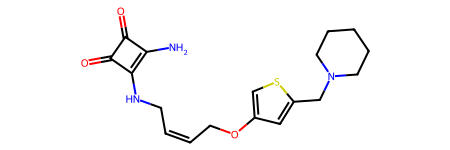

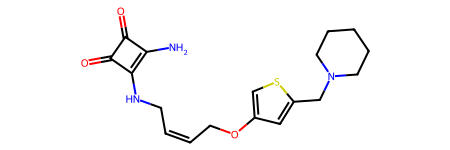

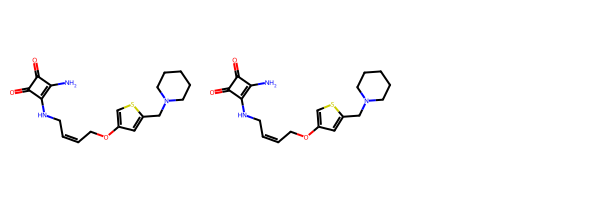

False


In [8]:
nrm=Normalizer()
m=Chem.MolFromSmiles(df_list_cleaned[0]["smiles"][0])
m2 = nrm.normalize(m)
display(m2)
display(m)
display(Draw.MolsToGridImage([m,m2]))
print(m==m2)



In [9]:
nrm = Normalizer()

def valid_smiles(smiles):

    if not isinstance(smiles, str):
        return None

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    try:
        mol = nrm.normalize(mol)
        return Chem.MolToSmiles(mol, canonical=True)
    except:
        return None

[13:54:59] Initializing Normalizer


In [10]:
for df in df_list_cleaned:
    df["valid_smiles"] = df["smiles"].apply(valid_smiles)

df_valid_0 = df_list_cleaned[0].loc[df_list_cleaned[0]["valid_smiles"].notna()].copy()
df_valid_1 = df_list_cleaned[1].loc[df_list_cleaned[1]["valid_smiles"].notna()].copy()

[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59] Running Normalizer
[13:54:59]

Calculate Morgan Fingerprints (`GetMorganGenerator`). You can experiment with other fingerprints (`GetRDKitFPGenerator`) as well and see how they impact the clusters.

In [11]:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
def smiles_to_fp(smiles):
    # string!!!!!!
    if not isinstance(smiles, str):
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    fp = mfpgen.GetFingerprint(mol)
    return fp

In [12]:
# Convert to fingerprints
fps_0 = []
valid_labels_0 = []
for cid, smiles in zip(df_valid_0["cid"], df_valid_0["valid_smiles"]):

    fp = smiles_to_fp(smiles)

    if fp is not None:
        fps_0.append(fp)
        valid_labels_0.append(cid)

# Convert df_list_cleaned[1] to fingerprints


fps_1 = []
valid_labels_1 = []
for cid, smiles in zip(df_valid_1["cid"], df_valid_1["valid_smiles"]):

    fp = smiles_to_fp(smiles)

    if fp is not None:
        fps_1.append(fp)
        valid_labels_1.append(cid)

[13:55:04] WARNING: not removing hydrogen atom without neighbors
[13:55:04] WARNING: not removing hydrogen atom without neighbors
[13:55:04] WARNING: not removing hydrogen atom without neighbors
[13:55:04] WARNING: not removing hydrogen atom without neighbors
[13:55:04] WARNING: not removing hydrogen atom without neighbors
[13:55:04] WARNING: not removing hydrogen atom without neighbors
[13:55:04] WARNING: not removing hydrogen atom without neighbors


> check that everything is iO

Butina Clustering: Investigate later how different cutoffs for the similarity affect the clusters.

> for df[0]

In [13]:
# Butina clustering requires distance matrix (distance = Tanimoto similarity); 
# fingerprints provided as list in this snippet - adjust as needed!
fp_list_0=fps_0.copy()
dists_0 = []
nfps_0 = len(fp_list_0)

for i in range(1, nfps_0):
    similarities = DataStructs.BulkTanimotoSimilarity(fp_list_0[i], fp_list_0[:i])
    dists_0.extend([1-x for x in similarities])

# Apply Butina Clustering

# Apply different thresholds later and see how they affect the clustering
cutoff = 0.6  # Tanimoto similarity threshold; e.g. 04 for larger chemical families, 0.7 for tight analogues...

butina_clusters_0 = Butina.ClusterData(
    dists_0, # similarity based distance matrix
    nfps_0, # number of fingerprints
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(butina_clusters_0))

Number of clusters: 6824


> for df[1]

In [14]:
# Butina clustering requires distance matrix (distance = Tanimoto similarity); 
# fingerprints provided as list in this snippet - adjust as needed!
fp_list_1=fps_1.copy()
dists_1 = []
nfps_1 = len(fp_list_1)

for i in range(1, nfps_1):
    similarities = DataStructs.BulkTanimotoSimilarity(fp_list_1[i], fp_list_1[:i])
    dists_1.extend([1-x for x in similarities])

# Apply Butina Clustering

# Apply different thresholds later and see how they affect the clustering
cutoff = 0.6  # Tanimoto similarity threshold; e.g. 04 for larger chemical families, 0.7 for tight analogues...

butina_clusters_1 = Butina.ClusterData(
    dists_1, # similarity based distance matrix
    nfps_1, # number of fingerprints
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(butina_clusters_1))

Number of clusters: 542


In [15]:
# filter out small clusters, rare chemoptypes, ...
clusters_filtered_0 = [c for c in butina_clusters_0 if len(c) >= 10]

butina_labels_0 = np.full(nfps_0, -1)
for cluster_id, cluster in enumerate(clusters_filtered_0):
    for id in cluster:
        butina_labels_0[id] = cluster_id

sizes_0 = [len(c) for c in clusters_filtered_0]

print("clusters:", len(sizes_0))
print("mean size:", np.mean(sizes_0))
print("max size:", np.max(sizes_0))
print("singletons:", sum(s == 1 for s in sizes_0))

clusters: 31
mean size: 14.483870967741936
max size: 30
singletons: 0


In [16]:
# filter out small clusters, rare chemoptypes, ...
clusters_filtered_1 = [c for c in butina_clusters_1 if len(c) >= 10]

butina_labels_1 = np.full(nfps_1, -1)
for cluster_id, cluster in enumerate(clusters_filtered_1):
    for id in cluster:
        butina_labels_1[id] = cluster_id

sizes_1 = [len(c) for c in clusters_filtered_1]

print("clusters:", len(sizes_1))
print("mean size:", np.mean(sizes_1))
print("max size:", np.max(sizes_1))
print("singletons:", sum(s == 1 for s in sizes_1))

clusters: 49
mean size: 28.06122448979592
max size: 125
singletons: 0


HDBSCAN Clustering: Inspect how `min_cluster_size` and `min_samples` affect the clusters later on. This might depend quite a lot on the dataset (try 15 and 5 for the PubChem data, <10 and <5 for the ChEMBL)

In [17]:
# use HDBSCAN for clustering
hdbs_clustering_0 = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=2,
    metric="euclidean"
)

hdbs_labels_0 = hdbs_clustering_0.fit_predict(fp_list_0)
print(hdbs_labels_0)
# print("Number of DBSCAN clusters:",
#       len(set(hdbs_labels)) - (1 if -1 in hdbs_labels else 0))
# print("Noise points:", list(hdbs_labels).count(-1))

[0 0 0 ... 0 0 0]


> I chose 5 and 2 bc 15 and 5 only gave me noise vals in hdbscan (-1) and no results, could be optimised

In [18]:
print(len(hdbs_labels_0))

9993


In [19]:
# use HDBSCAN for clustering
hdbs_clustering_1 = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=2,
    metric="euclidean"
)
hdbs_labels_1 = hdbs_clustering_1.fit_predict(fp_list_1)

In [20]:
print(len(hdbs_labels_1))

2358


In [21]:
print("Number of DBSCAN clusters:",
      len(set(hdbs_labels_0)) - (1 if -1 in hdbs_labels_0 else 0))
print("Noise points:", list(hdbs_labels_0).count(-1))

print("Number of DBSCAN clusters:",
      len(set(hdbs_labels_1)) - (1 if -1 in hdbs_labels_1 else 0))
print("Noise points:", list(hdbs_labels_1).count(-1))

Number of DBSCAN clusters: 2
Noise points: 114
Number of DBSCAN clusters: 133
Noise points: 863


Embeddings: TSNE and UMAP

In [22]:
# convert fingerprints to numpy
X_0 = np.zeros((nfps_0, 2048), dtype=int)
for i, fp in enumerate(fp_list_1):
    DataStructs.ConvertToNumpyArray(fp, X_0[i])

In [23]:
# convert fingerprints to numpy
X_1 = np.zeros((nfps_1, 2048), dtype=int)
for i, fp in enumerate(fp_list_1):
    DataStructs.ConvertToNumpyArray(fp, X_1[i])

In [24]:
# Dimensionality reduction by UMAP
umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.2,
    metric="jaccard",
    random_state=42
)

umap_embedding_0 = umap_model.fit_transform(X_0)
umap_embedding_1 = umap_model.fit_transform(X_1)

/Users/verityjanerothermelsmith/Library/Mobile Documents/com~apple~CloudDocs/Uni/FS2026/git/DSA104/.venv/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/Users/verityjanerothermelsmith/Library/Mobile Documents/com~apple~CloudDocs/Uni/FS2026/git/DSA104/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/verityjanerothermelsmith/Library/Mobile Documents/com~apple~CloudDocs/Uni/FS2026/git/DSA104/.venv/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(


In [25]:
# Dimensionality reduction by TSNE
tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_embedding_0 = tsne_model.fit_transform(X_0)
tsne_embedding_1 = tsne_model.fit_transform(X_1)

Visualise the two clustering methods in the two embeddings (e.g. as subplot). Make sure to label the axes properly.

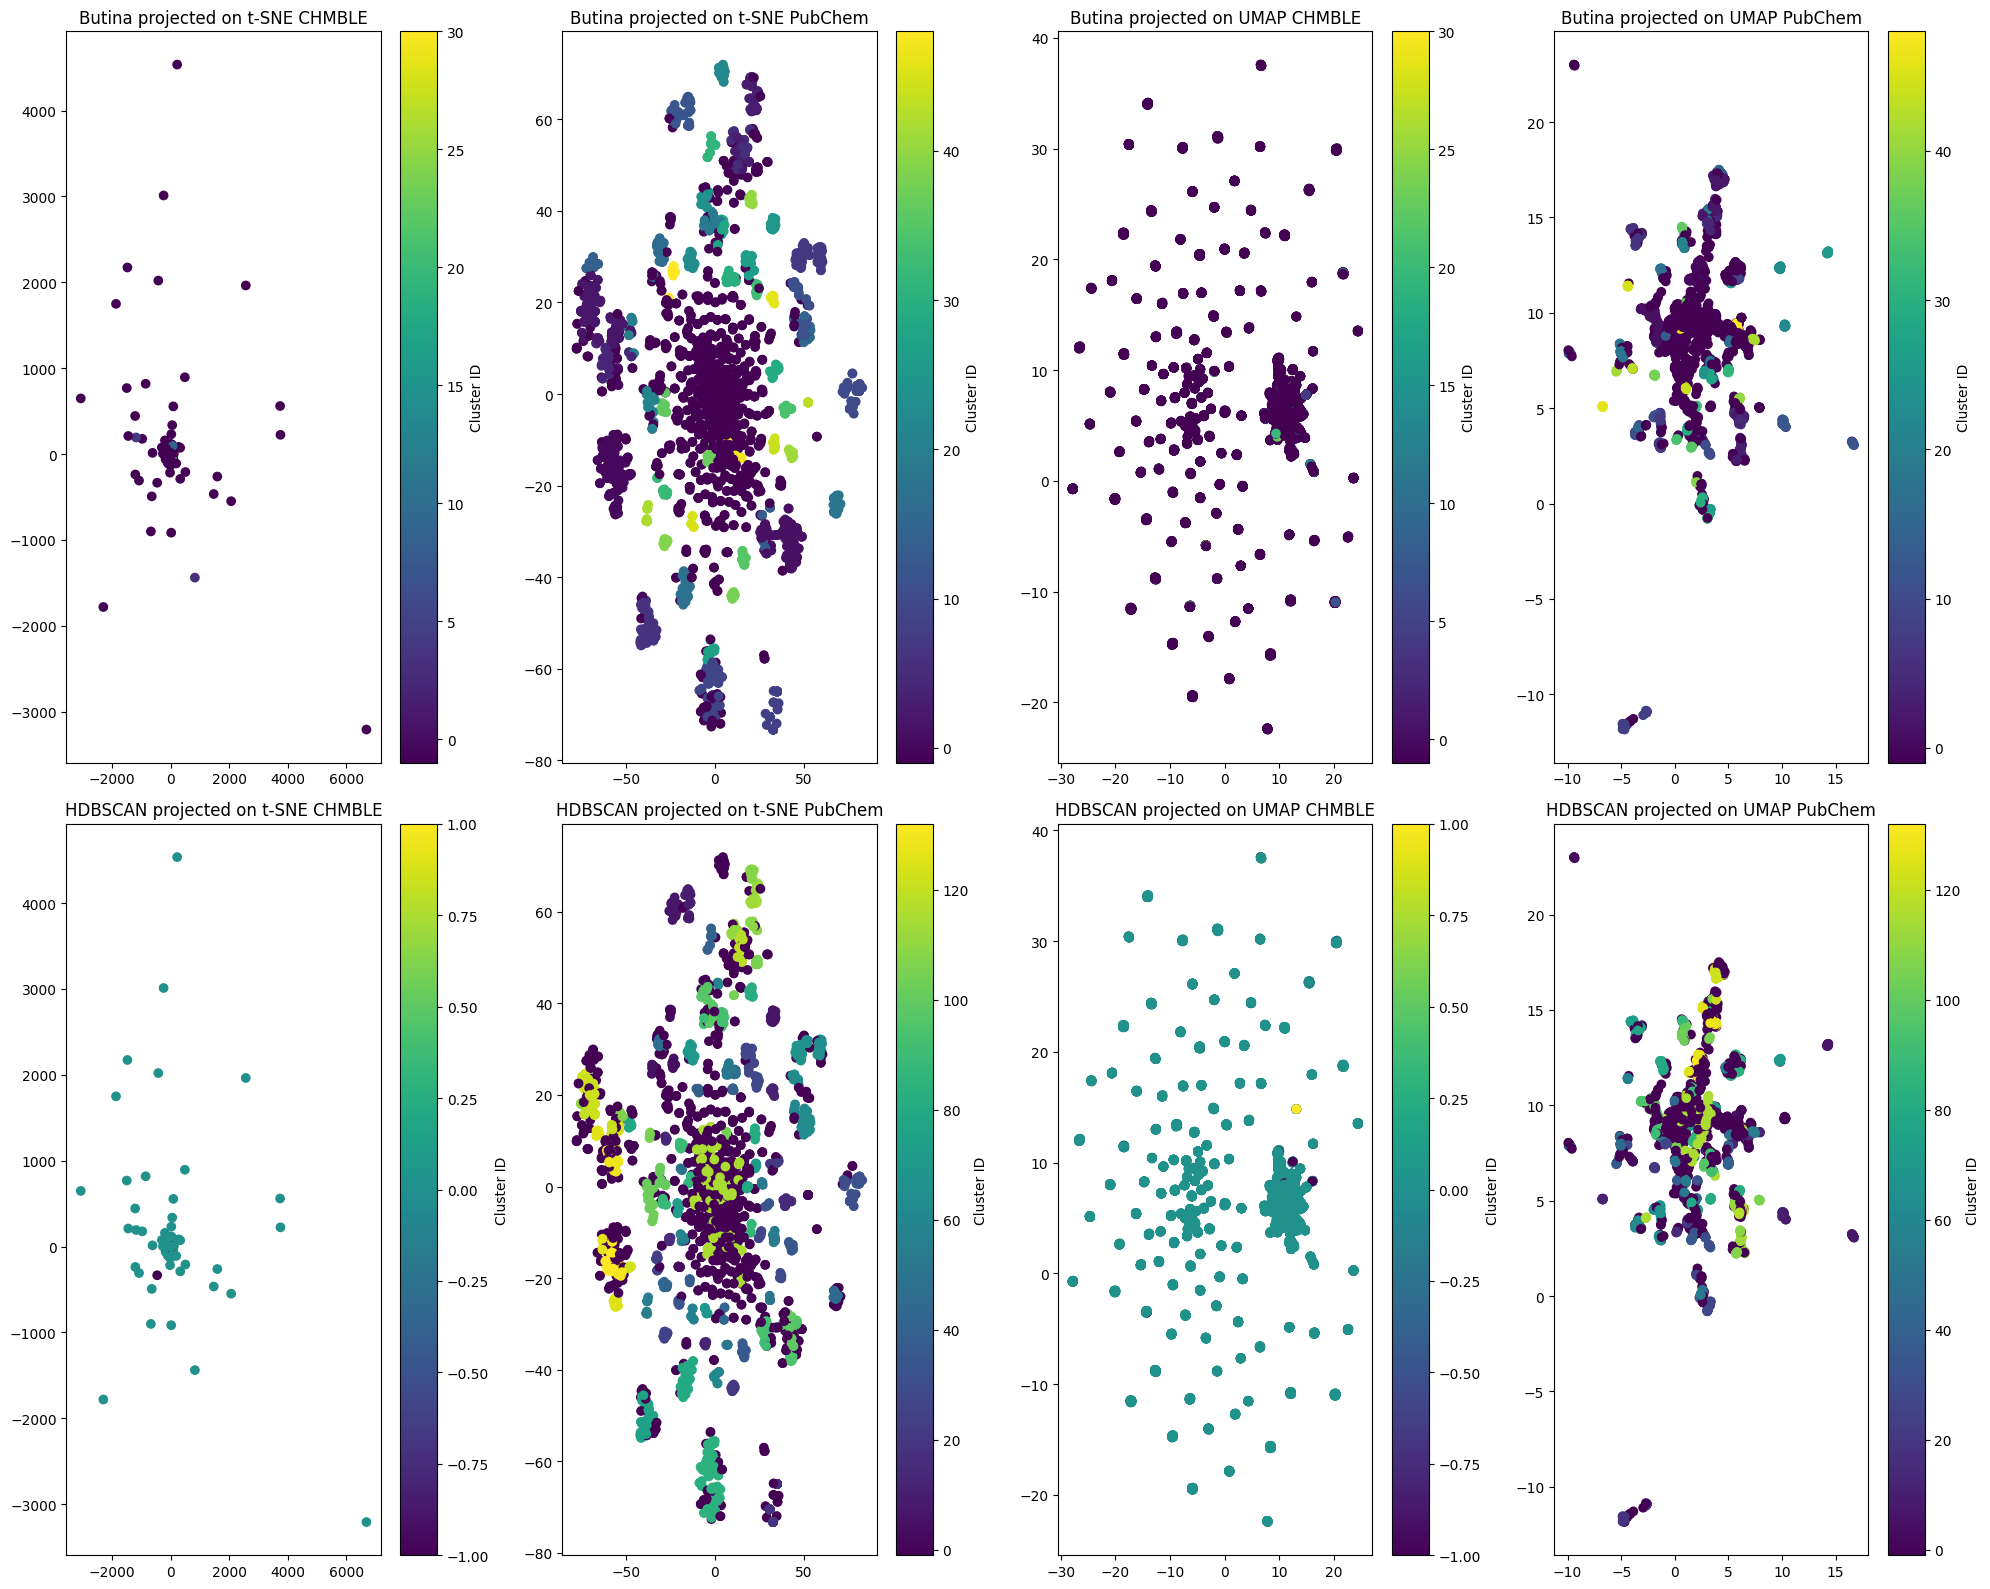

In [62]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 16))


# Butina projected on t-SNE

sc1=axes[0, 0].scatter(tsne_embedding_0[:, 0], tsne_embedding_0[:, 1], c=butina_labels_0)
axes[0, 0].set_title("Butina projected on t-SNE CHMBLE")
#axes[0, 0].colorbar(label="Cluster ID")

sc2=axes[0, 1].scatter(tsne_embedding_1[:, 0], tsne_embedding_1[:, 1], c=butina_labels_1)
axes[0, 1].set_title("Butina projected on t-SNE PubChem")

# Butina projected on UMAP

sc3=axes[0, 2].scatter(umap_embedding_0[:, 0], umap_embedding_0[:, 1], c=butina_labels_0)
axes[0, 2].set_title("Butina projected on UMAP CHMBLE")


sc4=axes[0, 3].scatter(umap_embedding_1[:, 0], umap_embedding_1[:, 1], c=butina_labels_1)
axes[0, 3].set_title("Butina projected on UMAP PubChem")




# DBSCAN projected on t-SNE

sc5=axes[1, 0].scatter(tsne_embedding_0[:, 0], tsne_embedding_0[:, 1], c=hdbs_labels_0)
axes[1, 0].set_title("HDBSCAN projected on t-SNE CHMBLE")

sc6=axes[1, 1].scatter(tsne_embedding_1[:, 0], tsne_embedding_1[:, 1], c=hdbs_labels_1)
axes[1, 1].set_title("HDBSCAN projected on t-SNE PubChem")

sc7=axes[1, 2].scatter(umap_embedding_0[:, 0], umap_embedding_0[:, 1], c=hdbs_labels_0)
axes[1, 2].set_title("HDBSCAN projected on UMAP CHMBLE")

sc8=axes[1, 3].scatter(umap_embedding_1[:, 0], umap_embedding_1[:, 1], c=hdbs_labels_1)
axes[1, 3].set_title("HDBSCAN projected on UMAP PubChem")


fig.colorbar(sc1, ax=axes[0,0], label="Cluster ID")
fig.colorbar(sc2, ax=axes[0,1], label="Cluster ID")
fig.colorbar(sc3, ax=axes[0,2], label="Cluster ID")
fig.colorbar(sc4, ax=axes[0,3], label="Cluster ID")
fig.colorbar(sc5, ax=axes[1,0], label="Cluster ID")
fig.colorbar(sc6, ax=axes[1,1], label="Cluster ID")
fig.colorbar(sc7, ax=axes[1,2], label="Cluster ID")
fig.colorbar(sc8, ax=axes[1,3], label="Cluster ID")

# Adjusting layout
plt.tight_layout()

# Show the plots
plt.show()


Visualise representative molecules of the three biggest clusters of both methods.

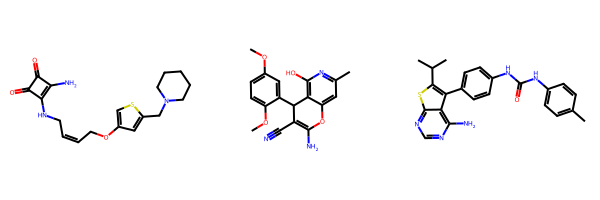

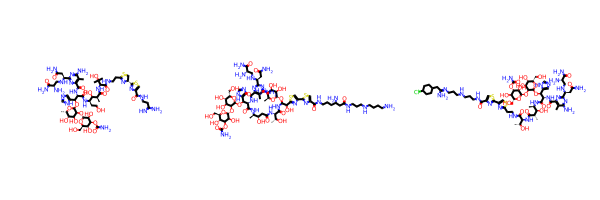

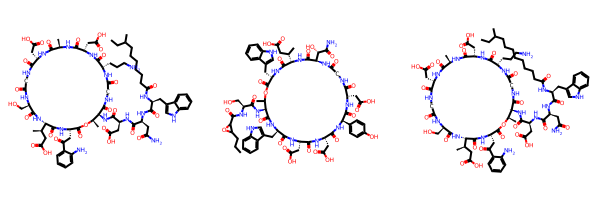

In [63]:
from rdkit import Chem
from rdkit.Chem import Draw

cluster_0 = df_valid_0[df_valid_0["HDBSCAN_cluster"] == 0].head(3)
cluster_1 = df_valid_1[df_valid_1["HDBSCAN_cluster"] == 0].head(3)
cluster_4 = df_valid_1[df_valid_1["HDBSCAN_cluster"] == 4].head(3)
mols_0 = [Chem.MolFromSmiles(sm) for sm in cluster_0["smiles"]]
mols_1 = [Chem.MolFromSmiles(sm) for sm in cluster_1["smiles"]]
mols_4 = [Chem.MolFromSmiles(sm) for sm in cluster_4["smiles"]]
display(Draw.MolsToGridImage(mols_0, molsPerRow=3))
display(Draw.MolsToGridImage(mols_1, molsPerRow=3))
display(Draw.MolsToGridImage(mols_4, molsPerRow=3))

## Discussion points
1) What are the characteristics of the chemical spaces described in the two dataset? What is the difference?
2) How do density-based clustering techniques compare to models based on similarity in light of the differences in the datasets?
3) What were the best model parameters for the clustering techniques (i.e. that delivered a meaningful result)
4) Comment on the different dimensionality reduction techniques (again in light of the different dataset characteristics)
5) What was the best / most meaningful combination of dimensionality reduction and clustering methods?
6) Comment on some cheminformatics modelling challenges you may have encountered (e.g. runtime, singleton clusters, paramtersensitivity). What could be done to work around a large number of clusters of small size?
7) On the antibiotics dataset, can you identify some known antibiotic classes / motives in your clusters?


1) CHemble very divers and heterogenous, large chemspace. PubChem more clusters with more hemically related groups of molecules, dense. 

2) butina worked well due to clustering based on simiarlity, HDBSCAN (density) only worked after reducing min cluster size and min samples. results okay (?).
3) butina cut off 0.6 worked well, for HDBSCAN for both min cluster size 5 and min samples 2. CHEMBL sata set didn't work with 15 and 5 bc very heterogeneous. 

4) tsne not vey healpful for chembl data, okay for pubchem. UMAP showed more for chembl data, easier to interpret.

5) HDBSCAN looks the same as Butina distribution, not sure why? different scales, but also different clustering technqiues. 
UMAP CHEMBLE GOOD, Butina better tsne.

6) long run times for hdbs clustering for chembl (3.33m)
also for UMAP reduction (1.7min)
parameters very important for heterogenous data sets, bc threshhold too high, no clusters :( 
 7) yes, for instance in row 4 of pubchem data (cf. visualised below, 3rd row), all contain very strange rings. Could imaging, that some beta lactams are also present, could find. 